In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
df = pd.read_csv("Advertising.csv")

df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:

# X, y 생성
X = df.drop('sales', axis=1)
y = df['sales']

# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)



In [4]:
# SCALE DATA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


In [5]:
from sklearn.linear_model import Ridge

# 1️⃣ alpha=100 : 규제가 매우 강한 모델
model = Ridge(alpha=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, y_pred)


7.34177578903413

In [6]:
# 2️⃣ alpha=1 : 규제를 완화
model = Ridge(alpha=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mean_squared_error(y_test, y_pred)


2.319021579428752

In [7]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

# Ridge 모델 객체
ridge = Ridge()

# 하이퍼파라미터 후보값 정의
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 200]}

# GridSearchCV 설정
grid = GridSearchCV(
    estimator=ridge,         # 모델
    param_grid=param_grid,   # 실험할 파라미터
    scoring='neg_mean_squared_error',  # 평가 기준 (MSE의 음수값)
    cv=5,                    # 5-폴드 교차검증
    verbose=1                # 학습 과정 출력
)

# 모델 학습
grid.fit(X_train, y_train)

# 최적 파라미터와 그때의 성능 출력
print("최적의 alpha:", grid.best_params_)
print("최적의 평균 MSE:", -grid.best_score_)

# 최적 모델로 테스트 데이터 예측
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# 테스트셋 MSE 확인
test_mse = mean_squared_error(y_test, y_pred)
print("테스트 세트 MSE:", test_mse)


Fitting 5 folds for each of 7 candidates, totalling 35 fits
최적의 alpha: {'alpha': 0.1}
최적의 평균 MSE: 3.3438371173739396
테스트 세트 MSE: 2.300652700356323


In [8]:
# 1️⃣ 데이터 분리
X = df.drop('sales', axis=1)
y = df['sales']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

# 2️⃣ 데이터 표준화
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# 3️⃣ Ridge 모델 생성
from sklearn.linear_model import Ridge
model = Ridge(alpha=100)

# 4️⃣ 교차검증 함수 불러오기
from sklearn.model_selection import cross_val_score


# Ridge 모델 교차 검증 수행
scores = cross_val_score(
    model,               # 사용할 모델
    X_train, y_train,    # 훈련 데이터
    scoring='neg_mean_squared_error',  # 평가 기준 (MSE, 음수로 계산됨)
    cv=5                 # 5-폴드 교차검증
)

# 교차검증 결과 확인
print("개별 Fold의 MSE:", -scores)
print("평균 MSE:", -scores.mean())


개별 Fold의 MSE: [ 9.32552967  4.9449624  11.39665242  7.0242106   8.38562723]
평균 MSE: 8.215396464543607


In [9]:
# 1️⃣ 라이브러리 임포트
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2️⃣ 데이터 로드
iris = datasets.load_iris()
X = iris.data       # 특징 데이터
y = iris.target     # 라벨

# 3️⃣ train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,        # 30%를 테스트용으로
    random_state=42,      # 재현성을 위해 고정
    stratify=y            # 클래스 비율 유지
)


In [11]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 4️⃣ KNN 모델 생성
knn = KNeighborsClassifier(n_neighbors=5)  # k=5 기본값

# 5️⃣ 학습
knn.fit(X_train, y_train)

# 6️⃣ 예측
y_pred = knn.predict(X_test)

# 7️⃣ 평가
acc = accuracy_score(y_test, y_pred)
print("Accuracy (No Scaling):", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy (No Scaling): 0.9777777777777777

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      1.00      0.97        15
           2       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [13]:
# 1️⃣ 라이브러리 임포트
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 2️⃣ 데이터 로드
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 3️⃣ train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 4️⃣ 데이터 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5️⃣ SVM 모델 + GridSearchCV
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(SVC(), param_grid=svm_param_grid, cv=5)
svm_grid.fit(X_train_scaled, y_train)

# SVM 예측
y_pred_svm = svm_grid.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, y_pred_svm)
print("SVM Best Params:", svm_grid.best_params_)
print("SVM Accuracy:", svm_acc)
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))

# 6️⃣ KNN 모델 + GridSearchCV
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1: Manhattan, 2: Euclidean
}

knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid=knn_param_grid, cv=5)
knn_grid.fit(X_train_scaled, y_train)

# KNN 예측
y_pred_knn = knn_grid.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, y_pred_knn)
print("\nKNN Best Params:", knn_grid.best_params_)
print("KNN Accuracy:", knn_acc)
print("\nKNN Classification Report:\n", classification_report(y_test, y_pred_knn))


SVM Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
SVM Accuracy: 0.9111111111111111

SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


KNN Best Params: {'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}
KNN Accuracy: 0.9111111111111111

KNN Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.79      1.00      0.88        15
           2       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91   

In [15]:
# 1️⃣ 라이브러리 임포트
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 2️⃣ 데이터 로드
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 3️⃣ train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=17, stratify=y
)

# 4️⃣ 데이터 표준화 (SVM, KNN은 필요)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 5️⃣ SVM 모델 + GridSearchCV
# ===============================
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(SVC(), param_grid=svm_param_grid, cv=5)
svm_grid.fit(X_train_scaled, y_train)

y_pred_svm = svm_grid.predict(X_test_scaled)
print("SVM Best Params:", svm_grid.best_params_)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))

# ===============================
# 6️⃣ KNN 모델 + GridSearchCV
# ===============================
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid=knn_param_grid, cv=5)
knn_grid.fit(X_train_scaled, y_train)

y_pred_knn = knn_grid.predict(X_test_scaled)
print("KNN Best Params:", knn_grid.best_params_)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nKNN Classification Report:\n", classification_report(y_test, y_pred_knn))

# ===============================
# 7️⃣ Random Forest + GridSearchCV
# ===============================
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=rf_param_grid, cv=5)
rf_grid.fit(X_train, y_train)

y_pred_rf = rf_grid.predict(X_test)
print("Random Forest Best Params:", rf_grid.best_params_)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))


SVM Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
SVM Accuracy: 0.9333333333333333

SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.93      0.87      0.90        15
           2       0.88      0.93      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

KNN Best Params: {'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
KNN Accuracy: 0.9333333333333333

KNN Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.93      0.87      0.90        15
           2       0.88      0.93      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93     

In [16]:
# 1️⃣ 라이브러리 임포트
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 2️⃣ 데이터 로드
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 3️⃣ train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 4️⃣ 데이터 스케일링 (KNN은 거리 기반 모델이므로 권장)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5️⃣ KNN 모델 생성 및 학습
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# 6️⃣ 예측
y_pred = knn.predict(X_test_scaled)

# 7️⃣ 결과 출력
print("Predictions from the classifier:")
print(y_pred)
print("Actual target values:")
print(y_test)

# 8️⃣ 성능 평가
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Predictions from the classifier:
[2 1 1 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 1 1 1 1 1 0 1 2 1 0 2 0 0
 0 0 1 1 0 1 2 1]
Actual target values:
[2 1 2 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 2 1 1 1 1 0 2 2 1 0 2 0 0
 0 0 1 1 0 2 2 1]

Accuracy: 0.9111111111111111

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.79      1.00      0.88        15
           2       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



In [17]:
# 1️⃣ 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 2️⃣ 데이터 로드
df = pd.read_csv("mouse_viral_study.csv")

# 3️⃣ 2D feature 선택
X = df[['Med_1_mL', 'Med_2_mL']]
y = df['Virus Present']

# 4️⃣ train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 5️⃣ 스케일링 (SVM, KNN은 거리 기반)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

df

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1
...,...,...,...
395,2.884122,3.271748,1
396,7.290855,9.488672,0
397,7.895325,8.272529,0
398,2.690592,2.674979,1


=== SVM ===
Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120


=== KNN ===
Best Params: {'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



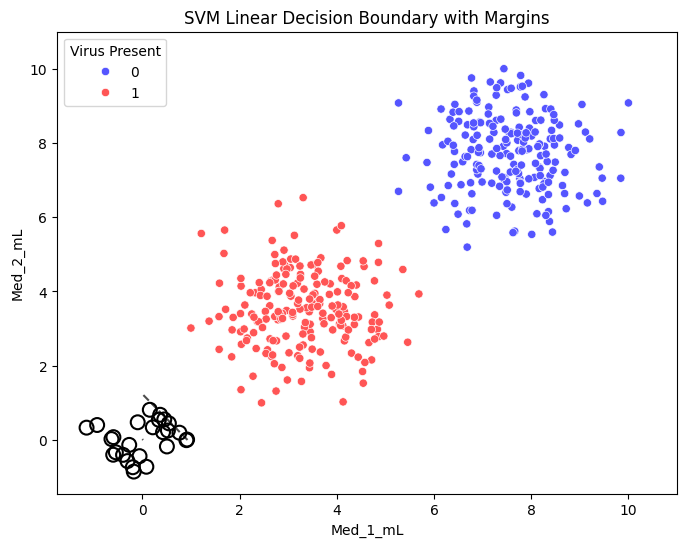

In [18]:
# ===============================
# 6️⃣ SVM 모델 + GridSearchCV
# ===============================
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(SVC(), param_grid=svm_param_grid, cv=5)
svm_grid.fit(X_train_scaled, y_train)

y_pred_svm = svm_grid.predict(X_test_scaled)
print("=== SVM ===")
print("Best Params:", svm_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# ===============================
# 7️⃣ KNN 모델 + GridSearchCV
# ===============================
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid=knn_param_grid, cv=5)
knn_grid.fit(X_train_scaled, y_train)

y_pred_knn = knn_grid.predict(X_test_scaled)
print("\n=== KNN ===")
print("Best Params:", knn_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


# ===============================
# 9️⃣ SVM 결정 경계 시각화 함수
# ===============================
def plot_svm_boundary(model, X, y, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,6))

    # Scatter plot
    sns.scatterplot(x=X.iloc[:,0], y=X.iloc[:,1], hue=y, palette='seismic', ax=ax)

    # Grid 생성
    x_min, x_max = X.iloc[:,0].min() - 1, X.iloc[:,0].max() + 1
    y_min, y_max = X.iloc[:,1].min() - 1, X.iloc[:,1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))

    # 결정 함수 계산
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 결정 경계 및 마진
    ax.contour(xx, yy, Z, colors='k', levels=[-1,0,1], alpha=0.7,
               linestyles=['--','-','--'])

    # 서포트 벡터
    ax.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1],
               s=100, facecolors='none', edgecolors='k', linewidths=1.5)

    ax.set_xlabel(X.columns[0])
    ax.set_ylabel(X.columns[1])
    ax.set_title("SVM Linear Decision Boundary with Margins")
    plt.show()

# 10️⃣ SVM 결정 경계 시각화
plot_svm_boundary(svm_grid.best_estimator_, X, y)


In [19]:
from sklearn import datasets
import pandas as pd

# 1️⃣ Iris 데이터 로드
iris = datasets.load_iris()

# 2️⃣ 라벨을 DataFrame으로 변환
labels = pd.DataFrame(iris.target)
labels.columns = ['labels']  # 라벨 컬럼 이름 지정

# 3️⃣ 특성 데이터를 DataFrame으로 변환
data = pd.DataFrame(iris.data)
data.columns = ['Sepal length','Sepal width','Petal length','Petal width']

# 4️⃣ 특성 + 라벨 합치기
data = pd.concat([data, labels], axis=1)

# 5️⃣ 상위 5개 확인
print(data.head())


   Sepal length  Sepal width  Petal length  Petal width  labels
0           5.1          3.5           1.4          0.2       0
1           4.9          3.0           1.4          0.2       0
2           4.7          3.2           1.3          0.2       0
3           4.6          3.1           1.5          0.2       0
4           5.0          3.6           1.4          0.2       0


In [20]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
feature = data[ ['Sepal length','Sepal width']]
feature.head()
# 1️⃣ KMeans 모델 생성
# algorithm='auto'는 최신 버전에서는 deprecated, 기본값 'lloyd' 사용
model = KMeans(n_clusters=3, random_state=42)

# 2️⃣ 모델 학습
model.fit(feature)  # feature는 DataFrame이나 numpy array

# 3️⃣ 클러스터 예측
predict = pd.DataFrame(model.predict(feature))
predict.columns = ['predict']

# 4️⃣ 예측값을 원본 데이터에 추가
r = pd.concat([feature, predict], axis=1)

# 5️⃣ 결과 출력
print(r.head())


   Sepal length  Sepal width  predict
0           5.1          3.5        2
1           4.9          3.0        2
2           4.7          3.2        2
3           4.6          3.1        2
4           5.0          3.6        2


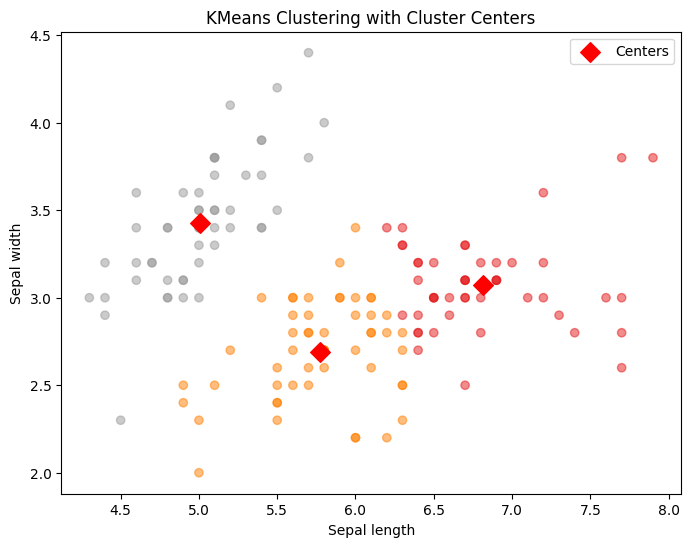

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# 1️⃣ 클러스터 센터 DataFrame 생성
centers = pd.DataFrame(model.cluster_centers_, columns=['Sepal length','Sepal width'])
center_x = centers['Sepal length']
center_y = centers['Sepal width']

# 2️⃣ scatter plot
plt.figure(figsize=(8,6))

# 데이터 포인트
plt.scatter(r['Sepal length'], r['Sepal width'], c=r['predict'], alpha=0.5, cmap='Set1')

# 클러스터 센터
plt.scatter(center_x, center_y, s=100, marker='D', c='red', label='Centers')

plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('KMeans Clustering with Cluster Centers')
plt.legend()
plt.show()


In [22]:
ct = pd.crosstab(data['labels'],r['predict'])
print (ct)

predict   0   1   2
labels             
0         0   0  50
1        12  38   0
2        35  15   0


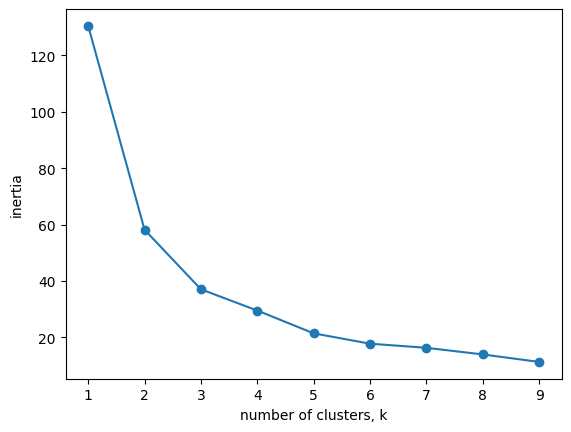

In [23]:
ks = range(1,10)
inertias = []

for k in ks:
    model = KMeans(n_clusters=k)
    model.fit(feature)
    inertias.append(model.inertia_)

# Plot ks vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

